**Problem 1 (100 pontos)**

Consider the system presented in Example 4.

(a) Construct a function that simulates this system, taking as inputs $N$ (number of events), $s$ (number of servers), $ρ$(system load), and $τ$ (average departure time).

In [ ]:
import numpy as np

# seed
rng = np.random.default_rng(123)

# simulation
def simulate_loss_system(N: int, s: int, rho: float, tau: float, rng=None) -> float:
    if rng is None:
        rng = np.random.default_rng()

    lam = rho / tau  # arrivals per second
    # mu = 1 / tau   # (for reference)

    t = 0.0
    t_next_arrival = rng.exponential(1.0 / lam)
    departure_times = []  # absolute times

    total_arrivals = 0
    blocked = 0

    while total_arrivals < N:
        t_next_departure = min(departure_times) if departure_times else np.inf

        if t_next_arrival <= t_next_departure:
            # Arrival
            t = t_next_arrival
            total_arrivals += 1

            if len(departure_times) < s:
                # Accept: schedule departure
                service_time = rng.exponential(tau)
                departure_times.append(t + service_time)
            else:
                # Block
                blocked += 1

            # schedule next arrival
            t_next_arrival = t + rng.exponential(1.0 / lam)
        else:
            # Departure
            t = t_next_departure
            departure_times.remove(t_next_departure)

    return blocked / total_arrivals


(b) Using the constructed function, plot a graph showing blocking probability curves as a function of load (ranging from 0.05 to 1 erlang, with steps of 0.05). 

Consider: 

$N = 200,000$, 

$τ = 10 seconds$, 

$s ∈ [1, 2]$. 

This graph will present two curves, one for each value of $s$.

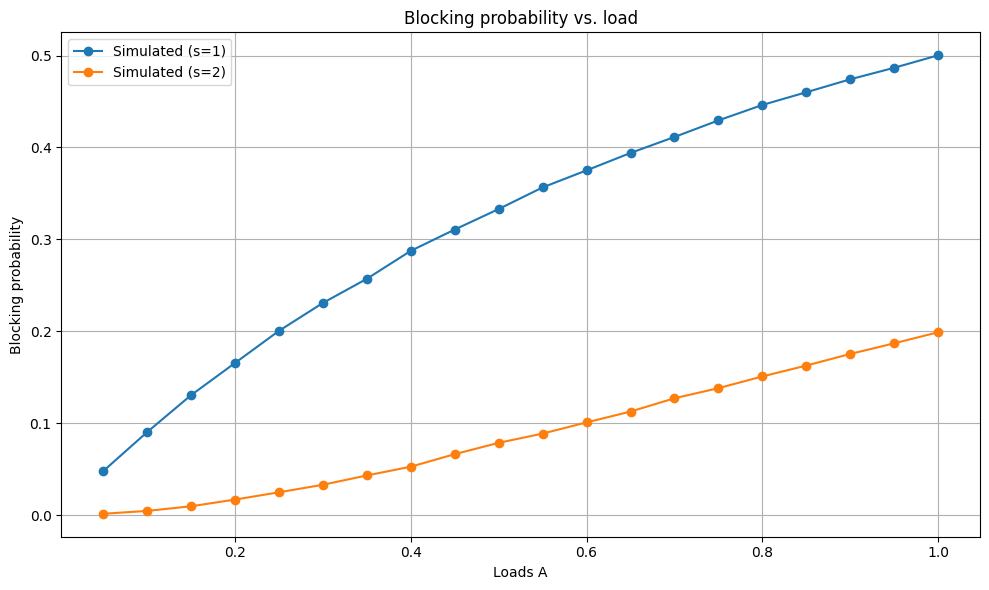

In [2]:
import matplotlib.pyplot as plt

# Parameters
N = 200_000
tau = 10.0  # seconds
loads = np.arange(0.05, 1.0 + 1e-9, 0.05)  # 0.05 ... 1.00 (step 0.05)
s_values = [1, 2]

sim_results = {1: [], 2: []}
for s in s_values:
    for A in loads:
        sim_results[s].append(simulate_loss_system(N=N, s=s, rho=A, tau=tau))

plt.figure(figsize=(10,6))
for s in s_values:
    plt.plot(loads, sim_results[s], marker='o', label=f"Simulated (s={s})")
plt.title("Blocking probability vs. load")
plt.xlabel("Loads A")
plt.ylabel("Blocking probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


(c) Compare the results obtained in (b) with the theoretical results obtained using the Erlang-B formula, plotting the theoretical and simulated results on the same graph.

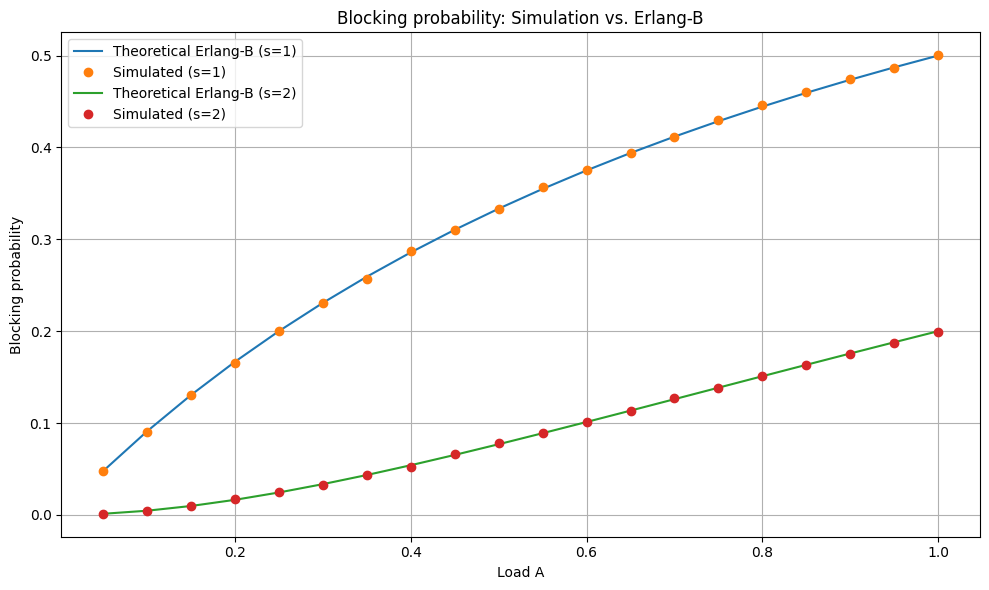

In [3]:
import math
import matplotlib.pyplot as plt

def erlangb(A, s):
    num = A**s / math.factorial(s)
    den = sum(A**i / math.factorial(i) for i in range(s+1))
    return num / den

theo_results = {
    1: [erlangb(A, 1) for A in loads],
    2: [erlangb(A, 2) for A in loads],
}

plt.figure(figsize=(10,6))
for s in [1, 2]:
    plt.plot(loads, theo_results[s], label=f"Theoretical Erlang-B (s={s})")
    plt.plot(loads, sim_results[s], marker='o', linestyle='None', label=f"Simulated (s={s})")

plt.title("Blocking probability: Simulation vs. Erlang-B")
plt.xlabel("Load A")
plt.ylabel("Blocking probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Comments**

The simulated blocking probabilities align almost perfectly with Erlang-B across all loads, validating the simulator. 

As traffic increases, blocking rises, and a two-server system ($s=2$) consistently shows substantially lower loss than a single server ($s=1$)

**Joker Problem 2 (100 pontos)**

Consider Example 5, assuming: 

 - $n = 200,000$;

 - $S = 1$;

 - $L = 2$;

 - $λ = 0.8$; 

 - $τ = 1$. 


Modify the code so that it is possible to obtain:

(a) The average number of customers in the queue and the average number of customers in the system.

(b) The average queue time and the average system time.

(c) From these results, verify the validity of Little's Theorem: